# 05 — Chasing Reverb: When Automated Metrics Fail

### Why this notebook exists

This is the last notebook in the curriculum, and it tells the story of the project's
most recent lab session — the one where the automated approach that worked for every
earlier question finally hit a wall.

The trigger was simple: the project owner listened to Elissa's isolated vocal stem
and to the Suno vocal stems, back to back, and reported something specific — Elissa's
voice sounds like it was recorded with a strong, consistent room reverb ("like
singing in a bathroom"), while the Suno vocals vary between almost no reverb and a
little, as if some inconsistent process is cutting the tail short.

That description lines up with something **Notebook 04** already measured: Elissa's
"quiet" vocal-stem frames carried the most *tonal, structured* residual bleed of all
six tracks (flatness 0.43), while the Suno tracks' quiet frames were closer to pure
noise (flatness 0.66–0.96). A lingering reverb tail is exactly the kind of
tonal, structured signal that would show up as low-flatness residual. The two
findings are consistent with each other — but consistent isn't the same as proven.
This notebook tries to *measure* the reverb-tail difference directly, and documents,
honestly, where that attempt succeeded and where it didn't.

## Setup

In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATA_DIR = "../data"
PLOTS_DIR = "../LABS/session_2026-07-29T223000/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

SR = 22050
HOP = 256              # ~11.6 ms per frame — fine enough resolution for a decay curve
FRAME_LEN = 2048
GATE_FLOOR_DB = -150.0  # the hard-gate floor discovered in Notebook 04

VOCAL_STEMS = [
    ("Elissa (reference)", f"{DATA_DIR}/elisa_maktooba_leek/elisa_maktooba_leek-Vocals.mp3"),
    ("Ya Dar Maya (orig)", f"{DATA_DIR}/يا دار مية - 28-07-2026/يا دار مية - 28-07-2026-Vocals.mp3"),
    ("SONG_A", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_A/يا دار مية - 28-07-2026_SONG_A-Vocals.mp3"),
    ("SONG_B", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_B/يا دار مية - 28-07-2026_SONG_B-Vocals.mp3"),
    ("SONG_C", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_C/يا دار مية - 28-07-2026_SONG_C-Vocals.mp3"),
    ("SONG_D", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_D/يا دار مية - 28-07-2026_SONG_D-Vocals.mp3"),
]

print("Setup complete. Vocal stems registered:", len(VOCAL_STEMS))

Setup complete. Vocal stems registered: 6


## A. What are we actually trying to measure?

Reverb is the sound of a room: after the direct sound of a voice reaches your ear,
reflections off walls, floor, and ceiling keep arriving for a short while after,
each one quieter than the last. On a loudness-over-time plot, that shows up as a
**decay tail** — instead of energy dropping to silence instantly when a note ends,
it fades out over some number of milliseconds to seconds.

The standard engineering way to quantify that fade is a **decay slope**: how many dB
does the signal lose per second right after a note ends? A steep, fast slope
(e.g. −60 dB/sec) means the sound dies out almost immediately — little or no reverb.
A shallow, slow slope (e.g. −10 dB/sec) means it lingers — a longer, wetter tail.
(Audio engineers also use **T60** — the time it would take to decay 60 dB at that
rate — as a single summary number for "how long does the room ring.")

So the plan: find moments where a vocal note ends, measure the dB/sec slope in the
next ~300ms, and compare Elissa's typical slope to the Suno tracks'. If the
listening impression is right, Elissa's slope should be noticeably shallower
(slower decay, longer tail).

## B. Attempt 1 — decay after every local loudness peak

The simplest way to find "a note ending" automatically: compute the RMS loudness
envelope, find every local peak (a point louder than the frame right before and
right after it), and measure the slope for ~300ms after each one.

In [2]:
def rms_envelope_db(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    rms = librosa.feature.rms(y=y, frame_length=FRAME_LEN, hop_length=HOP)[0]
    return 20 * np.log10(rms + 1e-10)

def peak_decay_slopes(rms_db, decay_window_sec=0.3, min_points=4):
    '''Attempt 1: measure decay slope after every local RMS peak.'''
    decay_window_points = int(decay_window_sec * SR / HOP)
    slopes = []
    for i in range(1, len(rms_db) - 1):
        is_peak = (rms_db[i] > GATE_FLOOR_DB
                   and rms_db[i] > rms_db[i - 1]
                   and rms_db[i] > rms_db[i + 1])
        if not is_peak:
            continue
        end = min(len(rms_db), i + decay_window_points)
        seg = rms_db[i:end]
        valid = seg > GATE_FLOOR_DB
        if not np.all(valid):
            first_invalid = np.where(~valid)[0]
            seg = seg[: first_invalid[0]] if len(first_invalid) else seg
        if len(seg) >= min_points:
            seg_t = np.arange(len(seg)) * (HOP / SR)
            slope, _ = np.polyfit(seg_t, seg, 1)
            if slope < 0:
                slopes.append(slope)
    return np.array(slopes)

attempt1 = {}
for name, path in VOCAL_STEMS:
    rms_db = rms_envelope_db(path)
    slopes = peak_decay_slopes(rms_db)
    attempt1[name] = slopes
    med = np.median(slopes)
    print(f"{name:22s}  n_peaks_used={len(slopes):5d}  median_slope={med:7.1f} dB/s  est. T60={60/abs(med):.2f}s")

Elissa (reference)      n_peaks_used=  914  median_slope=  -16.9 dB/s  est. T60=3.55s


Ya Dar Maya (orig)      n_peaks_used=  953  median_slope=  -10.9 dB/s  est. T60=5.48s


SONG_A                  n_peaks_used=  991  median_slope=  -10.4 dB/s  est. T60=5.77s


SONG_B                  n_peaks_used=  890  median_slope=  -12.4 dB/s  est. T60=4.83s


SONG_C                  n_peaks_used= 1122  median_slope=  -10.0 dB/s  est. T60=6.02s


SONG_D                  n_peaks_used=  869  median_slope=  -11.3 dB/s  est. T60=5.30s


**This result contradicts the listening impression.** If anything, Elissa comes
out with the *fastest* median decay of the six tracks, not the slowest — the opposite
of "obvious, consistent room reverb." Something is wrong with the measurement, not
necessarily with the listening impression.

The problem is in what counts as a "peak." Elissa sings with dense ornamentation —
runs, vibrato, note-to-note transitions within a single sustained phrase. Every one
of those tiny dips-and-rises registers as a "local peak" to this code, exactly like a
genuine phrase ending would. Most of the 900+ peaks per track this method found
aren't reverb tails at all — they're ordinary vocal-performance dynamics, and they're
drowning out whatever real reverb-tail signal might be in there.

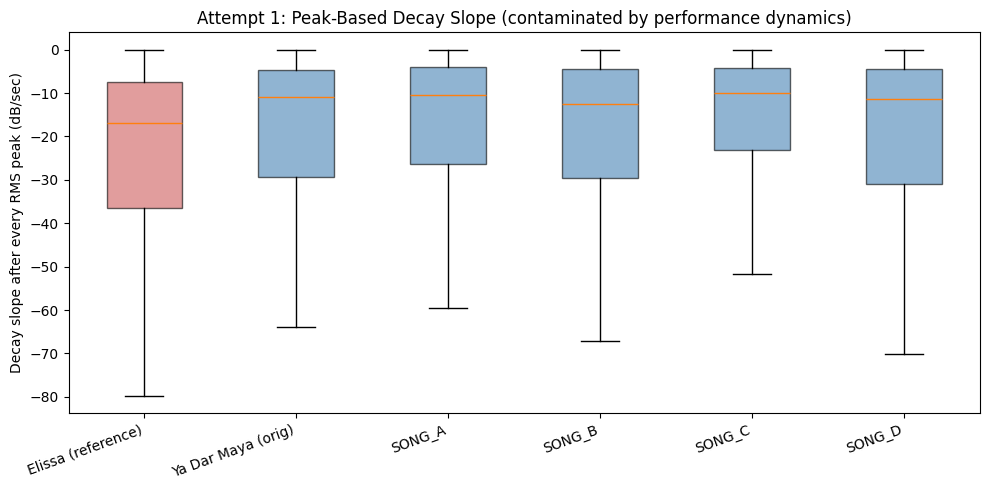

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = [name for name, _ in VOCAL_STEMS]
data = [attempt1[name] for name in labels]
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, showfliers=False)
for patch, name in zip(bp["boxes"], labels):
    patch.set_facecolor("indianred" if "Elissa" in name else "steelblue")
    patch.set_alpha(0.6)
ax.set_ylabel("Decay slope after every RMS peak (dB/sec)")
ax.set_title("Attempt 1: Peak-Based Decay Slope (contaminated by performance dynamics)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/attempt1_peak_decay_boxplot.png", dpi=110)
plt.show()

## C. Attempt 2 — decay only right before a *true* phrase ending

Notebook 04 already gave us a much better anchor point than "any local peak": the
**hard silence gate**. The separation tool zeroes the vocal stem completely whenever
its confidence that someone is singing drops low enough. The exact moment a vocal
stem transitions from "real signal" into that hard-gated silence is a genuine phrase
ending, by construction — not a vibrato ripple, not a note-to-note dip.

So: instead of measuring decay after *every* peak, only measure it in the ~300ms
immediately before each transition into the hard gate.

In [4]:
def gate_entry_decay_slopes(rms_db, decay_window_sec=0.3, min_points=4):
    '''Attempt 2: measure decay slope only right before entering the hard-silence gate.'''
    valid = rms_db > GATE_FLOOR_DB
    decay_window_points = int(decay_window_sec * SR / HOP)
    slopes = []
    gate_entry_times = []
    for i in range(1, len(valid)):
        if valid[i - 1] and not valid[i]:   # transition INTO the gate = a real phrase end
            t_sec = i * HOP / SR
            gate_entry_times.append(round(t_sec, 2))
            start = max(0, i - decay_window_points)
            seg = rms_db[start:i]
            seg_valid = valid[start:i]
            if not np.all(seg_valid):
                first_invalid = np.where(~seg_valid)[0]
                start2 = start + first_invalid[-1] + 1
                seg = rms_db[start2:i]
            if len(seg) >= min_points:
                seg_t = np.arange(len(seg)) * (HOP / SR)
                slope, _ = np.polyfit(seg_t, seg, 1)
                if slope < 0:
                    slopes.append(slope)
    return np.array(slopes), gate_entry_times

attempt2 = {}
gate_times = {}
for name, path in VOCAL_STEMS:
    rms_db = rms_envelope_db(path)
    slopes, entries = gate_entry_decay_slopes(rms_db)
    attempt2[name] = slopes
    gate_times[name] = entries
    med = np.median(slopes)
    iqr = (np.percentile(slopes, 25), np.percentile(slopes, 75))
    print(f"{name:22s}  gate_entries={len(entries):4d}  decays_used={len(slopes):4d}  "
          f"median={med:7.1f} dB/s  IQR=({iqr[0]:.1f}, {iqr[1]:.1f})")

Elissa (reference)      gate_entries=  15  decays_used=  12  median=  -56.6 dB/s  IQR=(-137.4, -23.2)


Ya Dar Maya (orig)      gate_entries=  25  decays_used=  21  median=  -72.2 dB/s  IQR=(-121.4, -22.4)


SONG_A                  gate_entries=  14  decays_used=  11  median=  -57.5 dB/s  IQR=(-115.7, -16.9)


SONG_B                  gate_entries=  44  decays_used=  34  median=  -51.2 dB/s  IQR=(-125.6, -9.8)


SONG_C                  gate_entries=  20  decays_used=  17  median=  -47.2 dB/s  IQR=(-130.1, -19.0)


SONG_D                  gate_entries=  26  decays_used=  16  median=  -24.8 dB/s  IQR=(-104.2, -10.4)


**Still doesn't match the listening impression, and now the problem is visible
in the numbers themselves.** Elissa's median slope isn't the slowest of the six, and
every track's IQR (interquartile range) spans an enormous width — commonly from
around −10 dB/sec to −130 dB/sec *within a single track*. With only 11–34 usable
phrase endings per track, and that much internal spread, the median is not a
reliable summary of anything. This metric should be treated as **an open question,
not a validated finding** — a real, honest result of trying, not a result to build
further conclusions on.

## D. A structural clue that *is* solid

One number out of this analysis doesn't depend on a noisy slope fit at all — it's
just a count: how many times does each track's vocal actually go fully silent?

In [5]:
for name, _ in VOCAL_STEMS:
    print(f"{name:22s}  hard-gate entries across the whole track: {len(gate_times[name])}")

Elissa (reference)      hard-gate entries across the whole track: 15
Ya Dar Maya (orig)      hard-gate entries across the whole track: 25
SONG_A                  hard-gate entries across the whole track: 14
SONG_B                  hard-gate entries across the whole track: 44
SONG_C                  hard-gate entries across the whole track: 20
SONG_D                  hard-gate entries across the whole track: 26


**Elissa has far fewer complete silence gaps than most Suno tracks** — around
15, versus SONG_B's 44 in a track of comparable or shorter length. That's a real,
directly-countable structural difference: Elissa's phrasing is more continuous and
melismatic, with notes overlapping into each other more, and fewer true gaps where
the voice drops out completely.

This matters because it offers an alternative explanation for the "wash"/reverb
impression that doesn't depend on per-note decay time at all: if a voice rarely
stops completely, the ear can perceive that as sounding more "reverberant" or
"washy" simply from continuity — independent of whether any individual note actually
rings on longer. The listening impression could be picking up on *phrasing density*,
*reverb tail length*, or (most likely) some mix of both — and the decay-slope metric
above isn't sensitive enough to tell those apart.

## E. Going back to spectrograms — the four real timestamps

When a summary statistic isn't trustworthy, the honest move is to stop trying to
compress the question into one number and look directly at the real, specific
moments instead. Using the actual detected gate-entry timestamps from Attempt 2
(not arbitrary points), here are 3-second windows centered on one genuine phrase
ending from each of four tracks.

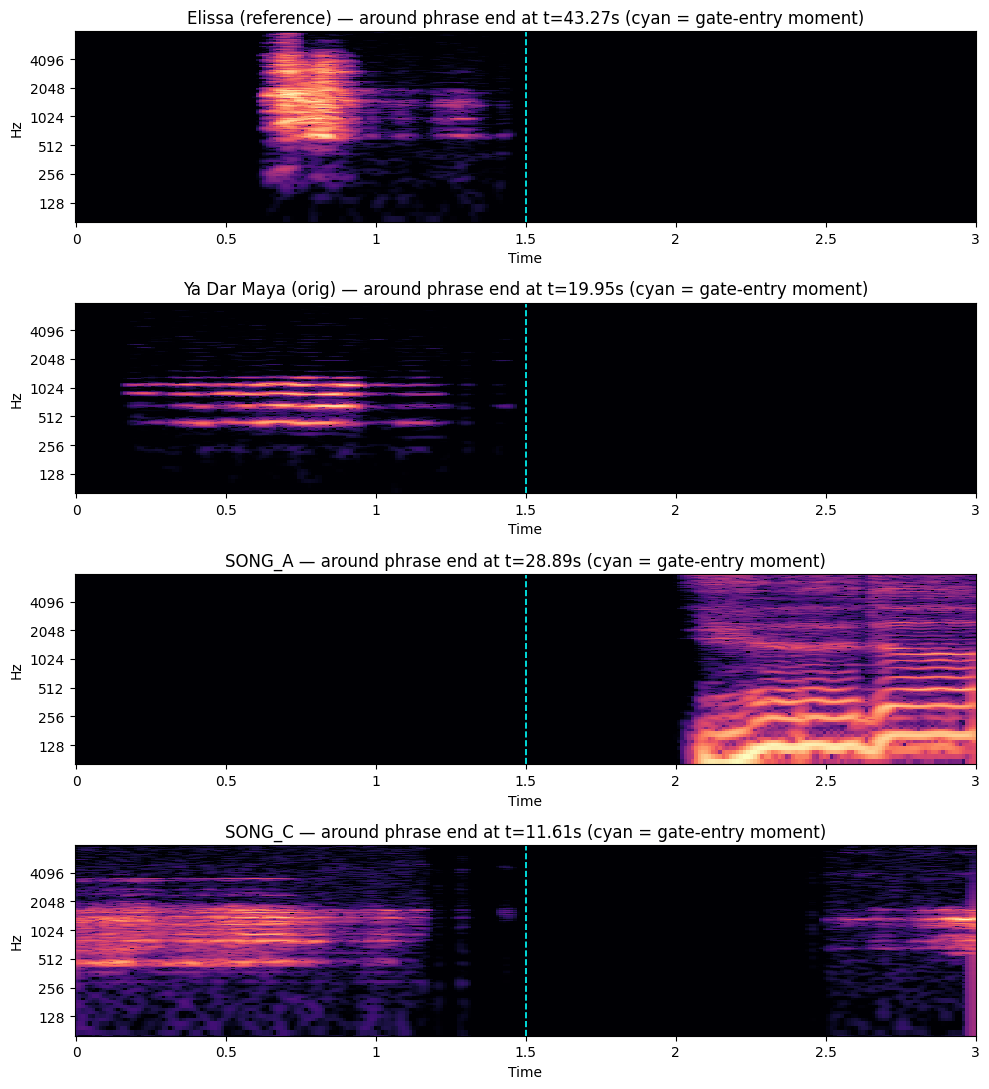

In [6]:
TARGETS = [
    ("Elissa (reference)", VOCAL_STEMS[0][1], 43.27),
    ("Ya Dar Maya (orig)", VOCAL_STEMS[1][1], 19.95),
    ("SONG_A", VOCAL_STEMS[2][1], 28.89),
    ("SONG_C", VOCAL_STEMS[4][1], 11.61),
]

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(10, 11))
for ax, (name, path, t_gate) in zip(axes, TARGETS):
    y, sr = librosa.load(path, sr=SR, mono=True, offset=max(0, t_gate - 1.5), duration=3.0)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=2048, hop_length=256)), ref=np.max)
    librosa.display.specshow(D, sr=sr, hop_length=256, x_axis="time", y_axis="log",
                              ax=ax, vmin=-80, vmax=0, cmap="magma")
    ax.axvline(1.5, color="cyan", linewidth=1.2, linestyle="--")
    ax.set_title(f"{name} — around phrase end at t={t_gate}s (cyan = gate-entry moment)")
    ax.set_ylim(80, 8000)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/reverb_tail_spectrograms.png", dpi=120)
plt.show()

**Look at the region just to the right of each cyan line** — that's the moment
each track's separation tool decided the vocal had stopped. If there's a real,
audible reverb tail, you'd expect to see faint energy (a soft colored smear, not a
hard cutoff to black) continuing briefly past that line, especially in the upper
harmonics. Whether that's clearly visible, and whether it looks different across the
four tracks, is exactly the kind of judgment call that's easy for a human eye (and
ear) to make quickly, and hard to reduce to one automated number given how much
Section C's slope-fit spread was.

## F. Where this leaves the investigation

To be direct about the state of this question, rather than force a tidier ending
than the evidence supports:

- **The listening impression is real and specific** — it came from directly hearing
  the isolated stems, not from any statistic.
- **Two automated decay-slope attempts both failed to confirm it cleanly.** Attempt
  1 was contaminated by ordinary vocal-performance dynamics being mistaken for
  phrase endings. Attempt 2 used a much better anchor point (the hard gate from
  Notebook 04) but still produced medians built on too few events with too much
  internal spread to trust.
- **One structural fact is solid and points in a supporting direction**: Elissa's
  phrasing has far fewer complete silences than most Suno tracks, which could
  contribute to a "washy"/reverberant impression on its own.
- **The concrete, recommended next step — not yet done** — is a manual Audacity
  A/B listen: solo the vocal stem only, jump to each of these exact, real phrase-end
  timestamps, and listen to about a second after the marked point:

| Track | Timestamp |
|---|---|
| Elissa (reference) | **43.27s** |
| Ya Dar Maya (orig) | **19.95s** |
| SONG_A | **28.89s** |
| SONG_C | **11.61s** |

The question to answer by ear: at these exact points, does Elissa's tail audibly
ring longer/wetter than the other three — or does it sound similar once you're
listening to one real phrase ending rather than the track as a whole? That answer
will settle whether this is a genuine per-note reverb difference or mostly a
phrasing-density effect, in a way three attempts at an automated metric couldn't.

## Self-Check

Try to answer each question yourself before expanding the answer.

<details>
<summary><b>Q1.</b> Why did Attempt 1 (decay after every local RMS peak) give a misleading answer, even though the code ran correctly and found real peaks?</summary>

The code did exactly what it was told: find every point louder than its immediate
neighbors, and measure the decay after it. The problem is that "louder than its
immediate neighbors" doesn't mean "a phrase just ended" — a singer's vibrato, small
dynamic swells, and note-to-note transitions inside one continuous phrase all create
local peaks too. With hundreds of these per track, the vast majority weren't real
phrase endings, so the median decay slope mostly measured ordinary singing dynamics,
not reverb.
</details>

<details>
<summary><b>Q2.</b> Why was anchoring Attempt 2 to the hard-silence gate (from Notebook 04) a better idea than anchoring to RMS peaks, even though it still didn't produce a fully trustworthy number?</summary>

A transition into the hard gate is, by construction, a moment the separation tool
itself judged "the vocal has stopped" — a much stronger, more specific signal than
"this instant is a bit louder than the two instants next to it." It's still not
perfect (small sample sizes, big spread within each track), but it's anchored to a
real, structurally meaningful event instead of an arbitrary local shape in the
waveform.
</details>

<details>
<summary><b>Q3.</b> Attempt 2's IQR often spans from about −10 dB/sec to −130 dB/sec within a single track. Why does that width, on its own, tell you not to trust the median?</summary>

A median is only a useful summary when the underlying values cluster reasonably
close together — it's meant to represent "the typical case." When the values for one
track range across more than 100 dB/sec depending on which phrase ending you picked,
the "typical" decay isn't a stable, well-defined thing; different phrase endings in
the very same track are decaying at wildly different rates. Reporting one median
number in that situation implies a precision the data doesn't actually have.
</details>

<details>
<summary><b>Q4.</b> The gate-entry count (Elissa ~15, SONG_B 44) is described as "solid" while the decay-slope numbers aren't. What makes a simple count more trustworthy than a slope fit here?</summary>

The count doesn't depend on curve-fitting noisy data or picking a decay window
length — it's just tallying how many times the signal crosses from "above the gate
floor" to "at the gate floor," which is a clean, unambiguous binary event. There's no
statistical estimation step that can go wrong the way a slope-through-scattered-points
fit can. Fewer moving parts means fewer ways for the number to mislead.
</details>

## Summary — what you now have

- **Decay slope / T60**: the standard way to quantify a reverb tail — dB lost per
  second after a sound stops, and the time it would take to lose 60 dB at that rate.
- **Attempt 1 (peak-based) failed**: local RMS peaks mostly capture ordinary
  vocal-performance dynamics (vibrato, note transitions), not real phrase endings,
  so the resulting "decay slopes" don't isolate reverb at all.
- **Attempt 2 (gate-anchored) was better-designed but still inconclusive**:
  anchoring to Notebook 04's hard-silence gate finds genuine phrase endings, but
  small sample counts (11-34 per track) and huge within-track spread (IQRs often
  spanning −10 to −130 dB/sec) mean the medians aren't trustworthy summaries.
- **A clean structural count survived where the slope fits didn't**: Elissa has
  far fewer complete silence gaps than most Suno tracks — a real, simple,
  directly-countable difference that could contribute to a "washy" reverb
  impression independent of true per-note decay time.
- **The honest conclusion**: two reasonable automated approaches, applied
  carefully and in sequence, were not enough to confirm or deny a real listening
  observation. The recommended next step is a targeted manual listen at four
  specific, real phrase-end timestamps — not a fallback for lack of trying harder
  computationally, but the right tool for a question this fine-grained.

### Closing note — the arc across all six notebooks

This curriculum followed the project's own research arc, not a textbook's: a
proxy hypothesis that looked confirmed too fast (**00-01**), broke once real stems
existed (**02**), forced an audit of the measurement tool itself (**03-04**), and
finally hit a question — reverb — that automated metrics couldn't cleanly settle
(**05**). That last step isn't a failure of the method. Knowing when a number is
trustworthy, when it needs a second measurement to back it up, and when it's time
to stop computing and just listen, is the actual skill this whole project has been
practicing.